# Taller — Regresión Exponencial y Regresión Logística
### Maestría en Informática — Curso *Aprendizaje Estadístico*

**Caso de estudio:** MiBolsillo — una fintech colombiana en expansión

Jeisson David Sanchez Gomez y Juan Daniel Bogotá Fuentes

---

## Contexto del caso

MiBolsillo es una fintech colombiana, con sede en Medellín, que ofrece una billetera digital y, desde hace unos meses, microcréditos de bajo monto para sus usuarios. La compañía atraviesa un momento decisivo: acaba de lanzar una campaña de referidos que disparó la adopción de la app, y al mismo tiempo necesita afinar su modelo de riesgo crediticio antes de escalar su producto de microcréditos a todo el país.

Como parte del equipo de Data Science de MiBolsillo, se deben resolver dos preguntas de negocio completamente distintas, aplicando los dos modelos vistos en clase:

- **Parte 1:** Regresión exponencial — crecimiento de usuarios nuevos por día tras la campaña de referidos.
- **Parte 2:** Regresión logística — riesgo de incumplimiento en microcréditos.

## Objetivo de aprendizaje

- Reconocer qué tipo de modelo corresponde a cada tipo de variable respuesta en un contexto de negocio nuevo.
- Ajustar e interpretar un modelo de regresión exponencial sobre una serie de crecimiento.
- Ajustar e interpretar un modelo de regresión logística sobre una variable de riesgo binaria, incluyendo odds ratios.
- Comunicar los resultados de ambos modelos en un lenguaje claro para la gerencia de MiBolsillo.

## Instrucciones generales

Para cada una de las dos partes de este taller, el notebook incluye, como mínimo, las siguientes secciones:

1. **Planteamiento del problema**: describir qué se quiere responder y por qué el tipo de variable respuesta exige el modelo correspondiente (exponencial o logístico).
2. **Análisis exploratorio**: al menos una visualización que soporte la elección de modelo.
3. **Ajuste del modelo**: código en Python que ajuste el modelo correspondiente.
4. **Interpretación de los coeficientes**: traducir los coeficientes del modelo a cantidades con sentido de negocio.
5. **Conclusión de negocio**: responder explícitamente la pregunta planteada por MiBolsillo.
6. **Limitaciones**: mencionar al menos una limitación o supuesto a tener en cuenta antes de tomar decisiones con base en el análisis.



## 0. Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import curve_fit

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Entorno listo.")


Entorno listo.


---
# Parte 1 — Crecimiento de usuarios tras la campaña de referidos

**Modelo esperado:** regresión exponencial

**Variable respuesta:** número de usuarios nuevos por día (conteo, crecimiento multiplicativo en el tiempo).

**Contexto:** Hace 10 días, MiBolsillo lanzó una campaña de referidos: cada usuario que invita a un amigo y este se registra, recibe un bono en la app. El equipo de Marketing ha visto que el número de usuarios nuevos por día viene creciendo aceleradamente, y necesita saber qué tan rápido está creciendo para dos decisiones muy concretas: cuántos servidores adicionales contratar para soportar la app, y cuándo el equipo de soporte al cliente empezará a saturarse si no se refuerza.


## 1.1 Datos del ejercicio

Código entregado por el enunciado (copiado tal cual).

In [2]:
np.random.seed(31)
dias = np.arange(0, 11)  # dia 0 a dia 10 desde el lanzamiento de la campaña
a_real, b_real = 120, 0.30
y_esperado = a_real * np.exp(b_real * dias)
ruido = np.random.normal(0, 1, size=len(dias)) * (y_esperado * 0.05)
usuarios_nuevos = np.clip(np.round(y_esperado + ruido), 1, None)
df_usuarios = pd.DataFrame({'dia': dias, 'usuarios_nuevos': usuarios_nuevos})
df_usuarios.head()


,dia,usuarios_nuevos
0,0,118.0
1,1,159.0
2,2,220.0
3,3,283.0
4,4,394.0


## 1.2 Planteamiento del problema

- MiBolsillo lanzó hace 10 días una campaña de referidos y el número de usuarios nuevos por día ha venido creciendo de forma acelerada. El equipo de Marketing necesita estimar qué tan rápido está creciendo esta cifra para tomar dos decisiones: Cuántos servidores adicionales contratar y en qué momento el equipo de soporte al cliente empezará a saturarse si no se refuerza.

- La tasa de cambio de la variable *-usuarios_nuevos-* no es constante, crece multiplicativamente, y este es el comportamiento que modela la regresión exponencial.


## 1.3 Análisis exploratorio



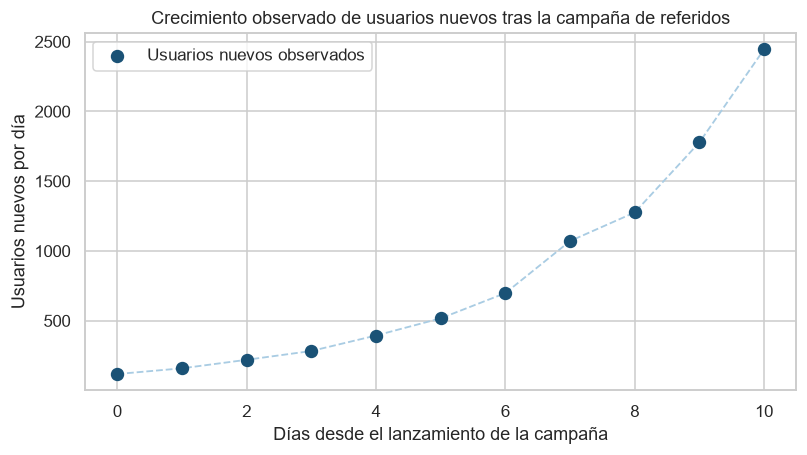

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.scatter(df_usuarios["dia"], df_usuarios["usuarios_nuevos"], color="#1a5276", s=60, zorder=3,
           label="Usuarios nuevos observados")
ax.plot(df_usuarios["dia"], df_usuarios["usuarios_nuevos"], color="#a9cce3", linestyle="--", lw=1.2, zorder=2)
ax.set_xlabel("Días desde el lanzamiento de la campaña")
ax.set_ylabel("Usuarios nuevos por día")
ax.set_title("Crecimiento observado de usuarios nuevos tras la campaña de referidos")
ax.legend()
plt.tight_layout()
plt.show()


## 1.4 Ajuste del modelo



In [4]:
df_usuarios["log_usuarios"] = np.log(df_usuarios["usuarios_nuevos"])

X = df_usuarios[["dia"]]              # scikit-learn espera una matriz 2D para los predictores
y_log = df_usuarios["log_usuarios"]   # variable respuesta transformada

modelo_exp = LinearRegression()
modelo_exp.fit(X, y_log)

b_estimado = modelo_exp.coef_[0]
a_estimado = np.exp(modelo_exp.intercept_)

print(f"Pendiente (b estimado):     {b_estimado:.4f}")
print(f"Intercepto (ln(a)):         {modelo_exp.intercept_:.4f}")
print(f"a estimado (valor inicial): {a_estimado:.3f}")
print(f"R² del modelo linearizado:  {modelo_exp.score(X, y_log):.4f}")

Pendiente (b estimado):     0.3029
Intercepto (ln(a)):         4.7640
a estimado (valor inicial): 117.215
R² del modelo linearizado:  0.9987


In [5]:
def funcion_exponencial(x, a, b):
    return a * np.exp(b * x)

parametros_opt, _ = curve_fit(funcion_exponencial, df_usuarios["dia"], df_usuarios["usuarios_nuevos"], p0=[100, 0.3])

print(f"a estimado (curve_fit): {parametros_opt[0]:.3f}")
print(f"b estimado (curve_fit): {parametros_opt[1]:.4f}")
print(f"\n(Compara estos valores con los obtenidos por linearización: a={a_estimado:.3f}, b={b_estimado:.4f})")

a estimado (curve_fit): 116.729
b estimado (curve_fit): 0.3037

(Compara estos valores con los obtenidos por linearización: a=117.215, b=0.3029)


## 1.5 Interpretación de los coeficientes



In [6]:
tasa_crecimiento_diaria = (np.exp(b_estimado) - 1) * 100
tiempo_duplicacion = np.log(2) / b_estimado

print(f"Usuarios nuevos el día 0 (a estimado):        {a_estimado:.1f}")
print(f"Tasa de crecimiento continuo diario (b):       {b_estimado:.4f}")
print(f"Tasa de crecimiento diaria efectiva:            {tasa_crecimiento_diaria:.1f}% por día")
print(f"Tiempo de duplicación estimado:                 {tiempo_duplicacion:.2f} días")

Usuarios nuevos el día 0 (a estimado):        117.2
Tasa de crecimiento continuo diario (b):       0.3029
Tasa de crecimiento diaria efectiva:            35.4% por día
Tiempo de duplicación estimado:                 2.29 días


- El modelo estima que el día del lanzamiento (día 0) hubo cerca de 117 usuarios nuevos, y que esta cifra crece a una tasa continua de 0.3029 por día — equivalente a un incremento efectivo de 35.4% cada día. En términos prácticos, el número de usuarios nuevos por día se está duplicando cada 2.29 días, un ritmo de crecimiento muy acelerado.

## 1.6 Conclusión de negocio

- El número de usuarios nuevos por día se duplica cada 2.29 días. Esto significa que la demanda no crecerá de forma gradual, sino que se multiplicará por más de 30 veces en solo dos semanas si la campaña sigue igual.

- Por eso, tanto los servidores adicionales como el refuerzo de soporte deben contratarse pensando en ciclos de duplicación de poco más de dos días, no en incrementos constantes. No es posible dar un número exacto de servidores o una fecha precisa de saturación sin conocer la capacidad de cada servidor o de cada agente de soporte, pero sí es claro que, sin refuerzo, la saturación ocurrirá en cuestión de días.

## 1.7 Limitaciones

- El modelo asume que el crecimiento exponencial se mantiene sin cambios, pero en la práctica todo crecimiento viral tiende a desacelerarse con el tiempo. Además, el ajuste se hizo con solo 11 días de datos, por lo que proyectar mucho más allá de ese rango puede sobreestimar el crecimiento real.

## 1.8 Preguntas guía

**a)** ¿Cuál es la tasa de crecimiento diaria estimada, y cada cuántos días se está duplicando el número de usuarios nuevos por día?

- La tasa de crecimiento continuo diario estimada es de 0.3029, lo que equivale a una tasa efectiva de aproximadamente 35.4% de crecimiento diario. Con este ritmo, el número de usuarios nuevos por día se duplica cada 2.29 días.

**b)** Si la tendencia se mantiene sin intervención, ¿cuántos usuarios nuevos se esperarían el día 20? ¿Qué tan confiable te parece esa proyección a ese horizonte?

- Si la tendencia se mantiene sin intervención, el modelo proyecta cerca de 50,122 usuarios nuevos para el día 20. Esta proyección es poco confiable: se está extrapolando a 10 días más allá del último dato observado (día 10), duplicando el horizonte de los datos usados para ajustar el modelo.

**c)** El equipo de Marketing quiere reportar el crecimiento como "aumentamos X usuarios nuevos por día" (un número fijo). Explica, con tus propias palabras y usando tu ajuste, por qué esa forma de reportarlo no es adecuada para este fenómeno.

- Reportar el crecimiento como "aumentamos X usuarios nuevos por día" implica un incremento constante, propio de una regresión lineal. Pero el ajuste muestra que el crecimiento es exponencial: cada día se suman más usuarios que el día anterior, porque el incremento es proporcional al valor ya alcanzado, no una cantidad fija. Un número fijo de "X usuarios por día" subestimaría fuertemente el crecimiento en los días siguientes y dejaría de ser válido casi de inmediato.

**d)** ¿Qué evento de negocio o de producto podría hacer que, en algún momento, este crecimiento deje de ser exponencial? ¿Cómo se vería reflejado eso en los datos?

- Algunos de los ejemplos de eventos podrian ser: Que se agote el bono de la campaña, que el mercado de usuarios potenciales se sature, que la app alcance límites de capacidad que generen caidas y desincentiven las invitaciones. En los datos, esto se vería como una desaceleración de la curva: los puntos dejarían de crecer multiplicativamente y empezarían a aplanarse, pareciéndose más a una curva logística.

In [7]:
# Codigo para contestar la pregunta b de las preguntas guia.

usuarios_dia_20 = a_estimado * np.exp(b_estimado * 20)
print(f"Usuarios nuevos proyectados el día 20: {usuarios_dia_20:.0f}")

Usuarios nuevos proyectados el día 20: 50122


---
# Parte 2 — Riesgo de incumplimiento en microcréditos

**Modelo esperado:** regresión logística

**Variable respuesta:** incumplimiento del crédito (binaria: sí/no).

**Contexto:** MiBolsillo lleva seis meses ofreciendo microcréditos dentro de la app. Antes de escalar el producto a nivel nacional, el área de Riesgo necesita un modelo que estime la probabilidad de que un solicitante incumpla su crédito, a partir de información que ya tiene disponible de cada usuario en el momento de la solicitud.


## 2.1 Datos del ejercicio

Código entregado por el enunciado (copiado tal cual).

In [8]:
np.random.seed(88)
n = 500
ingreso_mensual = np.random.normal(2200, 600, n).clip(min=400)   # miles de COP
monto_solicitado = np.random.normal(800, 300, n).clip(min=100)   # miles de COP
antiguedad_meses = np.random.normal(14, 7, n).clip(min=1)        # meses como usuario de la app
uso_otros_productos = np.random.binomial(1, 0.4, n)              # 1 = usa otros productos de MiBolsillo
pagos_tardios_historicos = np.random.poisson(0.8, n)             # pagos tardíos previos dentro de la app

ing_c = (ingreso_mensual - 2200) / 600
mon_c = (monto_solicitado - 800) / 300
ant_c = (antiguedad_meses - 14) / 7
tar_c = (pagos_tardios_historicos - 0.8) / 1

b0, b_ing, b_mon, b_ant, b_uso, b_tar = -1.1, -0.8, 0.55, -0.6, -0.7, 0.65
logit = b0 + b_ing*ing_c + b_mon*mon_c + b_ant*ant_c + b_uso*uso_otros_productos + b_tar*tar_c
prob = 1 / (1 + np.exp(-logit))
incumplimiento = np.random.binomial(1, prob)

df_credito = pd.DataFrame({
    'ingreso_mensual': ingreso_mensual,
    'monto_solicitado': monto_solicitado,
    'antiguedad_meses': antiguedad_meses,
    'uso_otros_productos': uso_otros_productos,
    'pagos_tardios_historicos': pagos_tardios_historicos,
    'incumplimiento': incumplimiento
})
df_credito.head()


,ingreso_mensual,monto_solicitado,antiguedad_meses,uso_otros_productos,pagos_tardios_historicos,incumplimiento
0,2264.130582,411.047980,21.348197,0,1,1
1,3523.489145,1048.344110,16.429151,0,1,0
2,2773.937616,894.042009,20.190011,0,0,0
3,2241.046660,688.304779,22.609139,0,0,0
4,2841.108289,1130.739601,16.028181,1,0,0


## 2.2 Planteamiento del problema

- MiBolsillo lleva seis meses ofreciendo microcréditos dentro de la app y, antes de escalar el producto a nivel nacional, el área de Riesgo necesita estimar la probabilidad de que un solicitante incumpla su crédito, a partir de información disponible en el momento de la solicitud (ingreso, monto solicitado, antigüedad como usuario, uso de otros productos y pagos tardíos previos).

- La variable incumplimiento es binaria, solo tiene dos opciones: El solicitante cumple o incumple su crédito. Con la regresion logística, podemos modelar directamente la probabilidad de incumplimiento mediante una funcion sigmoide,que siempre nos entegara valores entre 0 y 1 que nos permitaran una mejor interpretacion de cada variable.


## 2.3 Análisis exploratorio



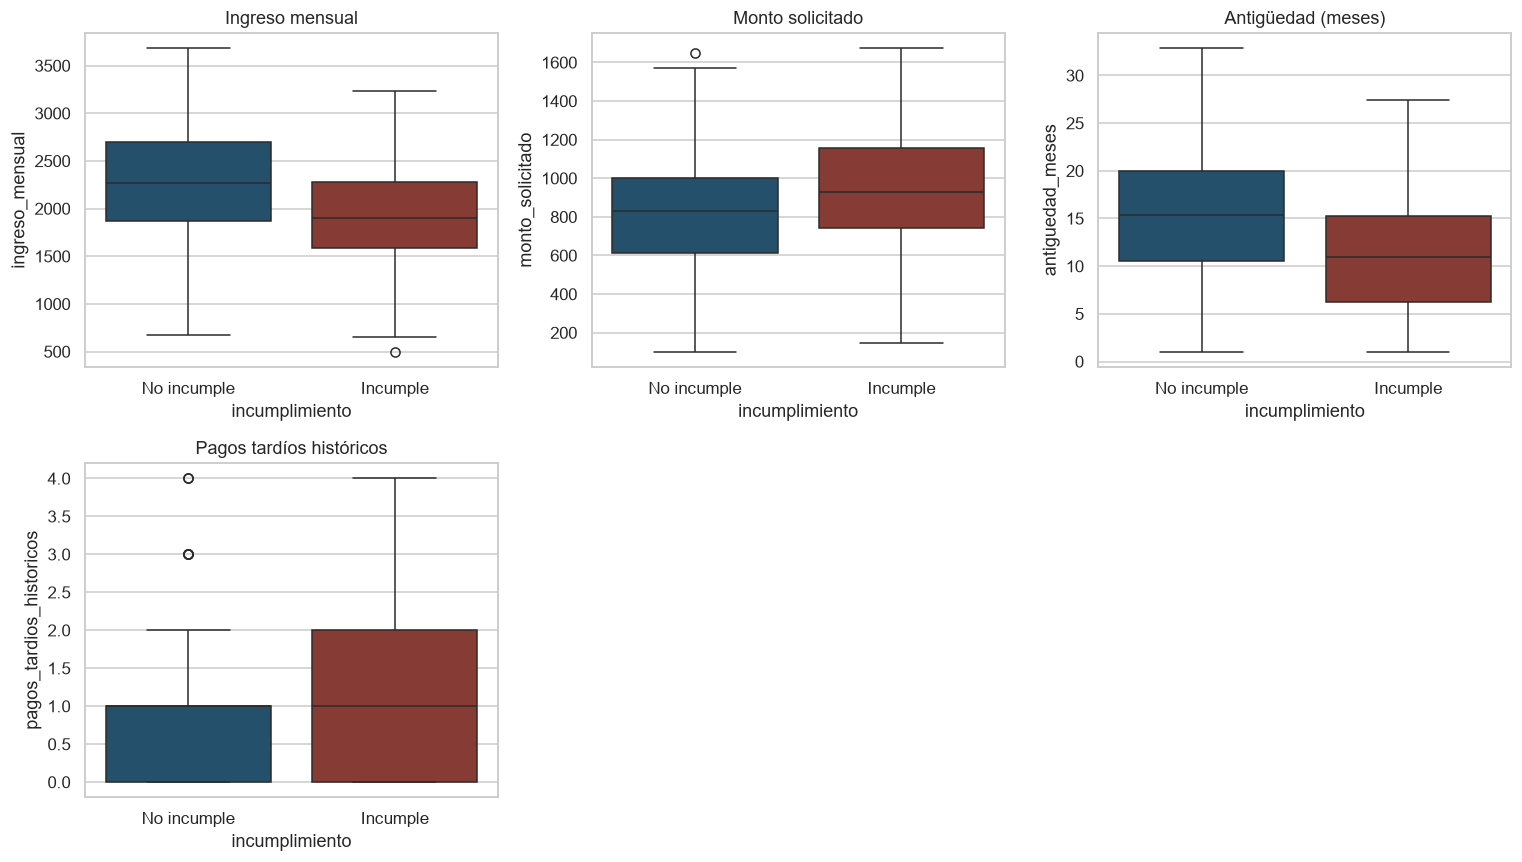

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

variables = ["ingreso_mensual", "monto_solicitado", "antiguedad_meses", "pagos_tardios_historicos"]
etiquetas = ["Ingreso mensual", "Monto solicitado", "Antigüedad (meses)", "Pagos tardíos históricos"]

for ax, var, etiqueta in zip(axes.flat, variables, etiquetas):
    sns.boxplot(data=df_credito, x="incumplimiento", y=var, hue="incumplimiento",
                palette=["#1a5276", "#943126"], legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No incumple", "Incumple"])
    ax.set_title(etiqueta)

axes[1, 1].axis("off")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

## 2.4 Ajuste del modelo



In [10]:
X_vars = ["ingreso_mensual", "monto_solicitado", "antiguedad_meses", "uso_otros_productos", "pagos_tardios_historicos"]
X = df_credito[X_vars]
y = df_credito["incumplimiento"]

X_con_constante = sm.add_constant(X)
modelo_logit = sm.Logit(y, X_con_constante).fit(disp=0)

print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:         incumplimiento   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:                            5
Date:                Fri, 11 Sep 2026   Pseudo R-squ.:                  0.2485
Time:                        18:57:08   Log-Likelihood:                -201.73
converged:                       True   LL-Null:                       -268.42
Covariance Type:            nonrobust   LLR p-value:                 4.525e-27
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        1.0560      0.666      1.586      0.113      -0.249       2.361
ingreso_mensual             -0.0013      0.000     -5.794      0.000      -0.002      -0.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

modelo_clf = LogisticRegression()
modelo_clf.fit(X_train_esc, y_train)

y_pred = modelo_clf.predict(X_test_esc)
y_proba = modelo_clf.predict_proba(X_test_esc)[:, 1]

print("Coeficientes (en escala estandarizada):")
for var, coef in zip(X_vars, modelo_clf.coef_[0]):
    print(f"  {var:22s}: {coef:+.3f}")

Coeficientes (en escala estandarizada):
  ingreso_mensual       : -0.755
  monto_solicitado      : +0.410
  antiguedad_meses      : -0.694
  uso_otros_productos   : -0.533
  pagos_tardios_historicos: +0.549


In [12]:
exactitud = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
matriz_confusion = confusion_matrix(y_test, y_pred)

print(f"Exactitud (accuracy):        {exactitud:.3f}")
print(f"Área bajo la curva ROC (AUC): {auc:.3f}")
print("\nMatriz de confusión:")
print(pd.DataFrame(matriz_confusion,
                    index=["Real: No incumple", "Real: Incumple"],
                    columns=["Predicho: No incumple", "Predicho: Incumple"]))

Exactitud (accuracy):        0.856
Área bajo la curva ROC (AUC): 0.874

Matriz de confusión:
                   Predicho: No incumple  Predicho: Incumple
Real: No incumple                     94                   3
Real: Incumple                        15                  13


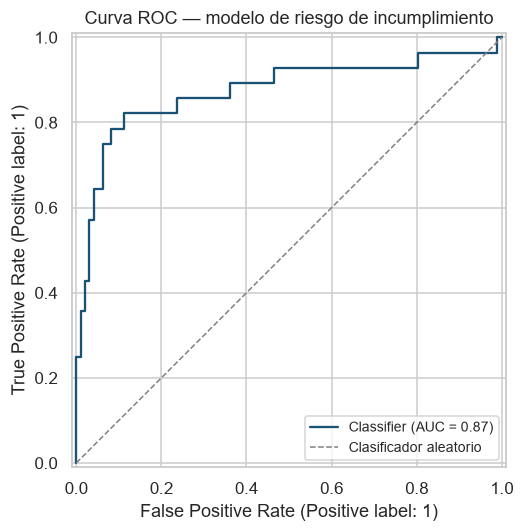

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.get_lines()[0].set_color("#1a5276")
ax.plot([0,1],[0,1], linestyle="--", color="grey", lw=1, label="Clasificador aleatorio")
ax.set_title("Curva ROC — modelo de riesgo de incumplimiento")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2.5 Interpretación de los coeficientes



In [14]:
odds_ratios = np.exp(modelo_logit.params)
tabla_or = pd.DataFrame({
    "Coeficiente (log-odds)": modelo_logit.params,
    "Odds Ratio": odds_ratios,
    "Valor p": modelo_logit.pvalues
}).round(4)
tabla_or

,Coeficiente (log-odds),Odds Ratio,Valor p
const,1.0560,2.8748,0.1128
ingreso_mensual,-0.0013,0.9987,0.0000
monto_solicitado,0.0019,1.0019,0.0000
antiguedad_meses,-0.1100,0.8958,0.0000
uso_otros_productos,-1.0824,0.3388,0.0001
pagos_tardios_historicos,0.7461,2.1087,0.0000


In [15]:
# Traducimos los odds ratios a porcentajes de cambio, en unidades con sentido de negocio

# Ingreso y monto están en MILES de COP -> los expresamos por cada 100 mil pesos (100 unidades)
or_ingreso_100k = np.exp(modelo_logit.params["ingreso_mensual"] * 100)
or_monto_100k = np.exp(modelo_logit.params["monto_solicitado"] * 100)

# Antigüedad está en meses -> la expresamos también por un año completo (12 meses)
or_antiguedad_1anio = np.exp(modelo_logit.params["antiguedad_meses"] * 12)

# Uso de otros productos (binaria) y pagos tardíos (conteo) ya están en su unidad natural
or_uso_productos = odds_ratios["uso_otros_productos"]
or_pagos_tardios = odds_ratios["pagos_tardios_historicos"]

print(f"Ingreso mensual (+100 mil COP):        {(or_ingreso_100k - 1)*100:+.1f}% en los momios de incumplimiento")
print(f"Monto solicitado (+100 mil COP):       {(or_monto_100k - 1)*100:+.1f}% en los momios de incumplimiento")
print(f"Antigüedad (+1 año / 12 meses):        {(or_antiguedad_1anio - 1)*100:+.1f}% en los momios de incumplimiento")
print(f"Uso de otros productos (0 -> 1):       {(or_uso_productos - 1)*100:+.1f}% en los momios de incumplimiento")
print(f"Pagos tardíos históricos (+1 pago):    {(or_pagos_tardios - 1)*100:+.1f}% en los momios de incumplimiento")

Ingreso mensual (+100 mil COP):        -12.5% en los momios de incumplimiento
Monto solicitado (+100 mil COP):       +21.4% en los momios de incumplimiento
Antigüedad (+1 año / 12 meses):        -73.3% en los momios de incumplimiento
Uso de otros productos (0 -> 1):       -66.1% en los momios de incumplimiento
Pagos tardíos históricos (+1 pago):    +110.9% en los momios de incumplimiento


- Las cinco variables resultaron estadísticamente significativas (p < 0.001). Un aumento de 100 mil pesos en el ingreso mensual reduce los momios de incumplimiento en 12.5%, mientras que el mismo incremento en el monto solicitado los aumenta en 21.4%, reflejando una relación directa entre capacidad de pago, tamaño del crédito y riesgo. Un año adicional de antigüedad como usuario de la app reduce los momios de incumplimiento en 73.3%, y el uso de otros productos de MiBolsillo los reduce en 66.1%, lo que sugiere que la relación previa del usuario con la plataforma es un fuerte indicador de menor riesgo. Por el contrario, cada pago tardío histórico adicional más que duplica los momios de incumplimiento (+110.9%), siendo la variable de mayor riesgo entre las cinco.

## 2.6 Conclusión de negocio



In [16]:
casos = pd.DataFrame({
    "perfil": [
        "Solicitante de la pregunta guía",
        "Perfil de bajo riesgo",
        "Perfil de riesgo medio",
        "Perfil de alto riesgo (más extremo)"
    ],
    "ingreso_mensual": [1400, 3000, 2200, 1000],
    "monto_solicitado": [1200, 500, 800, 1500],
    "antiguedad_meses": [4, 24, 12, 2],
    "uso_otros_productos": [0, 1, 0, 0],
    "pagos_tardios_historicos": [2, 0, 1, 3]
})

casos_esc = escalador.transform(casos[X_vars])
casos["probabilidad_incumplimiento"] = modelo_clf.predict_proba(casos_esc)[:, 1]

casos[["perfil", "probabilidad_incumplimiento"]]

,perfil,probabilidad_incumplimiento
0,Solicitante de la pregunta guía,0.898636
1,Perfil de bajo riesgo,0.005432
2,Perfil de riesgo medio,0.299834
3,Perfil de alto riesgo (más extremo),0.981631


- El modelo logístico ajustado responde la pregunta planteada por el área de Riesgo: permite estimar la probabilidad de incumplimiento de un solicitante a partir de información disponible al momento de la solicitud, con un desempeño adecuado (AUC = 0.874, exactitud = 85.6%). El error predominante son los falsos negativos, pues implica aprobar créditos que terminarán en incumplimiento.

- Al evaluar distintos perfiles, el modelo muestra una discriminación clara y consistente con la intuición de negocio: un solicitante con ingreso alto, monto bajo, alta antigüedad y buen historial de pagos obtiene una probabilidad de incumplimiento mínima (0.5%), mientras que un perfil con ingreso bajo, monto alto, poca antigüedad y varios pagos tardíos alcanza una probabilidad de incumplimiento superior al 98%. El solicitante evaluado en la pregunta guía (89.9% de probabilidad de incumplimiento) se ubica cerca de este extremo de alto riesgo, por lo que no se recomienda aprobar su microcrédito.

- En conjunto, estos resultados confirman que el modelo captura de forma coherente el efecto combinado de ingreso, monto solicitado, antigüedad, uso de otros productos y pagos tardíos históricos sobre el riesgo de incumplimiento, y constituye una herramienta útil para priorizar la revisión de solicitudes antes de escalar el producto a nivel nacional.

## 2.7 Limitaciones

- El modelo se entrenó con datos simulados de solo seis meses de historial, por lo que no captura posibles cambios estacionales o de comportamiento a más largo plazo. Además, al priorizar reducir los falsos negativos, es necesario evaluar si el umbral de decisión de 50% es el más adecuado, o si conviene ajustarlo para capturar más casos de incumplimiento a costa de rechazar algunos solicitantes que sí habrían pagado.

## 2.8 Preguntas guía

**a)** De las cinco variables disponibles, ¿cuáles resultan estadísticamente significativas para predecir el incumplimiento? Traduce el odds ratio de cada una a una frase de negocio.

- Ingreso mensual: cada 100 mil pesos adicionales de ingreso reduce los momios de incumplimiento en 12.5%.
- Monto solicitado: cada 100 mil pesos adicionales solicitados aumenta los momios de incumplimiento en 21.4%.
- Antigüedad en la app: cada año adicional de antigüedad reduce los momios de incumplimiento en 73.3%.
- Uso de otros productos de MiBolsillo: reduce los momios de incumplimiento en 66.1%.
- Pagos tardíos históricos: cada pago tardío adicional más que duplica (+110.9%) los momios de incumplimiento.

**b)** Divide los datos en entrenamiento y prueba, entrena el modelo con scikit-learn, y evalúa su desempeño (exactitud, matriz de confusión y AUC). ¿El modelo comete más falsos positivos o más falsos negativos? ¿Cuál de los dos errores le preocuparía más al área de Riesgo de MiBolsillo, y por qué?

- El modelo alcanzó una exactitud de 85.6% y un AUC de 0.874. Comete más falsos negativos (15) que falsos positivos (3): deja pasar como "no incumple" a más solicitantes que sí incumplirán, de los que clasifica erróneamente como riesgosos sin serlo. Para el área de Riesgo, los falsos negativos son el error más costoso, porque significan aprobar créditos que efectivamente no se pagarán, generando pérdida directa; un falso positivo solo implica rechazar a un buen pagador, un costo de oportunidad menor.

**c)** Usa tu modelo para estimar la probabilidad de incumplimiento de un solicitante con ingreso mensual de 1.400 (miles de COP), monto solicitado de 1.200 (miles de COP), 4 meses de antigüedad en la app, que no usa otros productos, y con 2 pagos tardíos históricos. ¿Aprobarías su microcrédito?

- Para ese solicitante (ingreso de 1.400 mil COP, monto de 1.200 mil COP, 4 meses de antigüedad, sin uso de otros productos, 2 pagos tardíos históricos), el modelo estima una probabilidad de incumplimiento de 89.9%. No se aprobaría el microcrédito: el perfil combina un monto alto relativo al ingreso, baja antigüedad y mal historial de pagos, los factores más asociados al riesgo según el modelo.

**d)** El área comercial de MiBolsillo propone aprobar automáticamente todo solicitante con probabilidad de incumplimiento menor al 50%. ¿Qué opinas de usar ese umbral fijo, considerando el volumen de solicitudes y el costo de cada tipo de error?

- Un umbral fijo de 50% ignora que los dos tipos de error no cuestan lo mismo para MiBolsillo: un falso negativo es más costoso que un falso positivo. Con un volumen alto de solicitudes, aplicar 50% de forma rígida dejaría pasar una proporción importante de incumplimientos, como ya se vio en la evaluación (15 falsos negativos frente a solo 3 falsos positivos). Sería más adecuado ajustar el umbral por debajo de 50% para priorizar la detección de incumplimientos, aceptando rechazar algunos solicitantes que sí habrían pagado, y revisar periódicamente ese umbral con datos reales de desempeño del producto.
